## 1. Initialize Project Environment
Import libraries for phylogenetic tree construction, clustering comparison, and visualization.

In [1]:
from __future__ import annotations

import json
import logging
from dataclasses import dataclass, asdict
from pathlib import Path
from typing import Dict, List, Tuple

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from Bio import Phylo, SeqIO
from Bio.Phylo.TreeConstruction import DistanceCalculator, DistanceTreeConstructor
from Bio.Align import MultipleSeqAlignment
from Bio.Seq import Seq
from Bio.SeqRecord import SeqRecord
from scipy.cluster.hierarchy import linkage, fcluster
from scipy.spatial.distance import squareform

logging.basicConfig(level=logging.INFO, format="[%(levelname)s] %(message)s")

## 2. Define Configuration Parameters
Centralize paths and tree construction settings.

In [2]:
@dataclass
class PhyloConfig:
    handle: str
    fasta_path: Path = None
    export_dir: Path = Path("artifacts")
    distance_model: str = "identity"
    n_clusters: int = 3

    def __post_init__(self):
        if self.fasta_path is None:
            self.fasta_path = Path(
                f"../../../data/work/{self.handle}/lab04/tp53_multi_sequences.fasta"
            )

    def describe(self) -> Dict[str, str]:
        info = asdict(self)
        info["fasta_path"] = str(info["fasta_path"])
        info["export_dir"] = str(info["export_dir"])
        return info


CONFIG = PhyloConfig(handle="AndreiCod")
CONFIG.describe()

{'handle': 'AndreiCod',
 'fasta_path': '../../../data/work/AndreiCod/lab04/tp53_multi_sequences.fasta',
 'export_dir': 'artifacts',
 'distance_model': 'identity',
 'n_clusters': 3}

In [3]:
def load_sequences(cfg: PhyloConfig) -> List[SeqRecord]:
    """Load sequences from Lab 4 FASTA file."""
    if not cfg.fasta_path.exists():
        raise FileNotFoundError(f"FASTA not found: {cfg.fasta_path}")

    records = list(SeqIO.parse(cfg.fasta_path, "fasta"))
    logging.info("Loaded %d sequences from %s", len(records), cfg.fasta_path)
    return records


sequences = load_sequences(CONFIG)
seq_ids = [rec.id for rec in sequences]
print(f"Loaded {len(sequences)} sequences")

[INFO] Loaded 10 sequences from ../../../data/work/AndreiCod/lab04/tp53_multi_sequences.fasta


Loaded 10 sequences


## 3. Build Phylogenetic Tree
Create alignment, compute distances, and construct Neighbor-Joining tree.

In [4]:
def create_padded_alignment(records: List[SeqRecord]) -> MultipleSeqAlignment:
    """Create alignment by padding sequences to equal length."""
    max_len = max(len(rec.seq) for rec in records)
    aligned = []

    for rec in records:
        padded_seq = str(rec.seq) + "-" * (max_len - len(rec.seq))
        aligned.append(SeqRecord(Seq(padded_seq), id=rec.id, description=""))

    return MultipleSeqAlignment(aligned)


alignment = create_padded_alignment(sequences)
logging.info(
    "Created alignment: %d sequences × %d bp",
    len(alignment),
    alignment.get_alignment_length(),
)

[INFO] Created alignment: 10 sequences × 5035 bp


In [5]:
def build_nj_tree(alignment: MultipleSeqAlignment, model: str = "identity"):
    """Build Neighbor-Joining tree from alignment."""
    calculator = DistanceCalculator(model)
    distance_matrix = calculator.get_distance(alignment)

    constructor = DistanceTreeConstructor()
    tree = constructor.nj(distance_matrix)

    return tree, distance_matrix


tree, bio_distance_matrix = build_nj_tree(alignment, CONFIG.distance_model)

print("Distance Matrix:")
print(bio_distance_matrix)
print("\nNeighbor-Joining Tree (ASCII):")
Phylo.draw_ascii(tree)

Distance Matrix:
NM_000546.6 0.000000
NM_011640.3 0.400596    0.000000
NM_131327.2 0.389275    0.346574    0.000000
XM_006719566.3  0.544786    0.575571    0.549553    0.000000
NM_001317019.1  0.820854    0.848659    0.830189    0.767627    0.000000
NM_001085860.1  0.414300    0.269315    0.359881    0.582125    0.857795    0.000000
XM_005194938.2  0.876663    0.909037    0.890566    0.832175    0.748957    0.912214    0.000000
NM_001006919.1  0.426018    0.283615    0.368620    0.585501    0.871698    0.270904    0.928898    0.000000
NM_001089263.1  0.371797    0.396624    0.370804    0.534657    0.820060    0.400000    0.885799    0.396226    0.000000
XM_031279688.1  0.454618    0.312413    0.402582    0.625819    0.902880    0.305462    0.961470    0.259583    0.441907    0.000000
    NM_000546.6 NM_011640.3 NM_131327.2 XM_006719566.3  NM_001317019.1  NM_001085860.1  XM_005194938.2  NM_001006919.1  NM_001089263.1  XM_031279688.1

Neighbor-Joining Tree (ASCII):
                      

In [6]:
def extract_tree_stats(tree) -> Dict:
    """Extract quantitative tree statistics."""
    terminals = list(tree.get_terminals())
    internals = list(tree.get_nonterminals())

    # Get branch lengths
    branch_lengths = [c.branch_length for c in tree.find_clades() if c.branch_length]

    stats = {
        "num_terminals": len(terminals),
        "num_internal_nodes": len(internals),
        "total_tree_length": round(sum(branch_lengths), 4) if branch_lengths else None,
        "mean_branch_length": round(sum(branch_lengths) / len(branch_lengths), 4)
        if branch_lengths
        else None,
        "terminal_names": [t.name for t in terminals],
    }

    return stats


tree_stats = extract_tree_stats(tree)

print("Tree Statistics:")
for k, v in tree_stats.items():
    if k != "terminal_names":
        print(f"  {k}: {v}")

Tree Statistics:
  num_terminals: 10
  num_internal_nodes: 8
  total_tree_length: 2.4589
  mean_branch_length: 0.1446


## 4. Load Clustering Results from Task 1
Load cluster assignments to compare with phylogenetic tree structure.

In [7]:
# Load cluster labels from Task 1
EXPORT_DIR = CONFIG.export_dir
cluster_labels_path = EXPORT_DIR / "task1_cluster_labels.csv"

if cluster_labels_path.exists():
    cluster_df = pd.read_csv(cluster_labels_path)
    logging.info("Loaded cluster labels from Task 1")
else:
    # Recompute if Task 1 hasn't been run
    logging.warning("Task 1 artifacts not found. Recomputing clusters...")

    # Simple p-distance computation
    def compute_p_distance(seq1: str, seq2: str) -> float:
        min_len = min(len(seq1), len(seq2))
        if min_len == 0:
            return 1.0
        s1, s2 = seq1[:min_len], seq2[:min_len]
        differences = sum(c1 != c2 for c1, c2 in zip(s1, s2))
        return differences / min_len

    n = len(sequences)
    distance_matrix = np.zeros((n, n))
    for i in range(n):
        for j in range(i + 1, n):
            dist = compute_p_distance(str(sequences[i].seq), str(sequences[j].seq))
            distance_matrix[i, j] = dist
            distance_matrix[j, i] = dist

    # Hierarchical clustering
    condensed = squareform(distance_matrix)
    Z = linkage(condensed, method="average")
    hc_labels = fcluster(Z, CONFIG.n_clusters, criterion="maxclust")

    cluster_df = pd.DataFrame(
        {
            "sequence_id": seq_ids,
            f"Hierarchical_K{CONFIG.n_clusters}": hc_labels,
        }
    )

cluster_df

[INFO] Loaded cluster labels from Task 1


,sequence_id,Hierarchical_K2,Hierarchical_K3,KMeans_K2,KMeans_K3,KMeans_K4,DBSCAN_eps0.3
0,NM_000546.6,2,2,0,1,3,-1
1,NM_011640.3,2,2,0,2,1,-1
2,NM_131327.2,2,2,0,2,1,-1
3,XM_006719566.3,1,1,1,0,0,-1
4,NM_001317019.1,2,3,1,0,0,-1
5,NM_001085860.1,2,3,1,0,2,-1
6,XM_005194938.2,2,3,1,0,2,-1
7,NM_001006919.1,1,1,0,2,1,-1
8,NM_001089263.1,1,1,1,1,0,-1
9,XM_031279688.1,2,2,0,1,3,-1


## 5. Compare Clusters with Tree Branches
Analyze whether sequences in the same cluster appear in the same clade.

In [8]:
def get_tree_clades(tree, n_clades: int = 3) -> Dict[str, int]:
    """Extract clade assignments from tree by depth-first traversal."""
    terminals = list(tree.get_terminals())

    # Get all clades and their terminal members
    clade_assignments = {}

    # Use hierarchical structure from tree
    # For simplicity, assign based on first major split
    root = tree.root

    def assign_clades(clade, clade_id, depth=0):
        """Recursively assign clade IDs."""
        if clade.is_terminal():
            clade_assignments[clade.name] = clade_id
        else:
            children = list(clade.clades)
            for i, child in enumerate(children):
                # Create new clade ID for major branches
                if depth == 0 and i < n_clades:
                    assign_clades(child, i + 1, depth + 1)
                else:
                    assign_clades(child, clade_id, depth + 1)

    assign_clades(root, 0)
    return clade_assignments


# Get tree clade assignments
tree_clades = get_tree_clades(tree, n_clades=CONFIG.n_clusters)
print("Tree Clade Assignments:")
for name, clade in tree_clades.items():
    print(f"  {name}: Clade {clade}")

Tree Clade Assignments:
  XM_005194938.2: Clade 1
  NM_001317019.1: Clade 1
  XM_006719566.3: Clade 1
  NM_000546.6: Clade 1
  NM_131327.2: Clade 2
  XM_031279688.1: Clade 2
  NM_001006919.1: Clade 2
  NM_001085860.1: Clade 2
  NM_011640.3: Clade 2
  NM_001089263.1: Clade 3


In [9]:
# Add tree clade to comparison DataFrame
cluster_df["Tree_Clade"] = cluster_df["sequence_id"].map(tree_clades)

# Select hierarchical clustering column for comparison
hc_col = [c for c in cluster_df.columns if c.startswith("Hierarchical_K")][0]

comparison_df = cluster_df[["sequence_id", hc_col, "Tree_Clade"]].copy()
comparison_df.columns = ["sequence_id", "Cluster", "Tree_Clade"]

print("Cluster vs Tree Clade Comparison:")
comparison_df

Cluster vs Tree Clade Comparison:


,sequence_id,Cluster,Tree_Clade
0,NM_000546.6,2,1
1,NM_011640.3,2,2
2,NM_131327.2,2,2
3,XM_006719566.3,1,1
4,NM_001317019.1,2,1
5,NM_001085860.1,2,2
6,XM_005194938.2,2,1
7,NM_001006919.1,1,2
8,NM_001089263.1,1,3
9,XM_031279688.1,2,2


In [10]:
def compute_agreement_metrics(df: pd.DataFrame) -> Dict:
    """Compute metrics comparing clustering with tree clades."""
    from sklearn.metrics import adjusted_rand_score, normalized_mutual_info_score

    clusters = df["Cluster"].values
    tree_clades = df["Tree_Clade"].values

    # Adjusted Rand Index: measures similarity between two clusterings
    ari = adjusted_rand_score(tree_clades, clusters)

    # Normalized Mutual Information
    nmi = normalized_mutual_info_score(tree_clades, clusters)

    # Contingency table
    contingency = pd.crosstab(df["Cluster"], df["Tree_Clade"])

    return {
        "adjusted_rand_index": round(ari, 4),
        "normalized_mutual_info": round(nmi, 4),
        "contingency_table": contingency,
    }


agreement = compute_agreement_metrics(comparison_df)

print(f"Adjusted Rand Index: {agreement['adjusted_rand_index']}")
print(f"Normalized Mutual Information: {agreement['normalized_mutual_info']}")
print("\nContingency Table (Cluster vs Tree Clade):")
agreement["contingency_table"]

Adjusted Rand Index: 0.0407
Normalized Mutual Information: 0.1747

Contingency Table (Cluster vs Tree Clade):


Tree_Clade,1,2,3
Cluster,,,
1,1,1,1
2,3,4,0


## 6. Visualize Annotated Tree
Create tree visualization with cluster labels annotated.

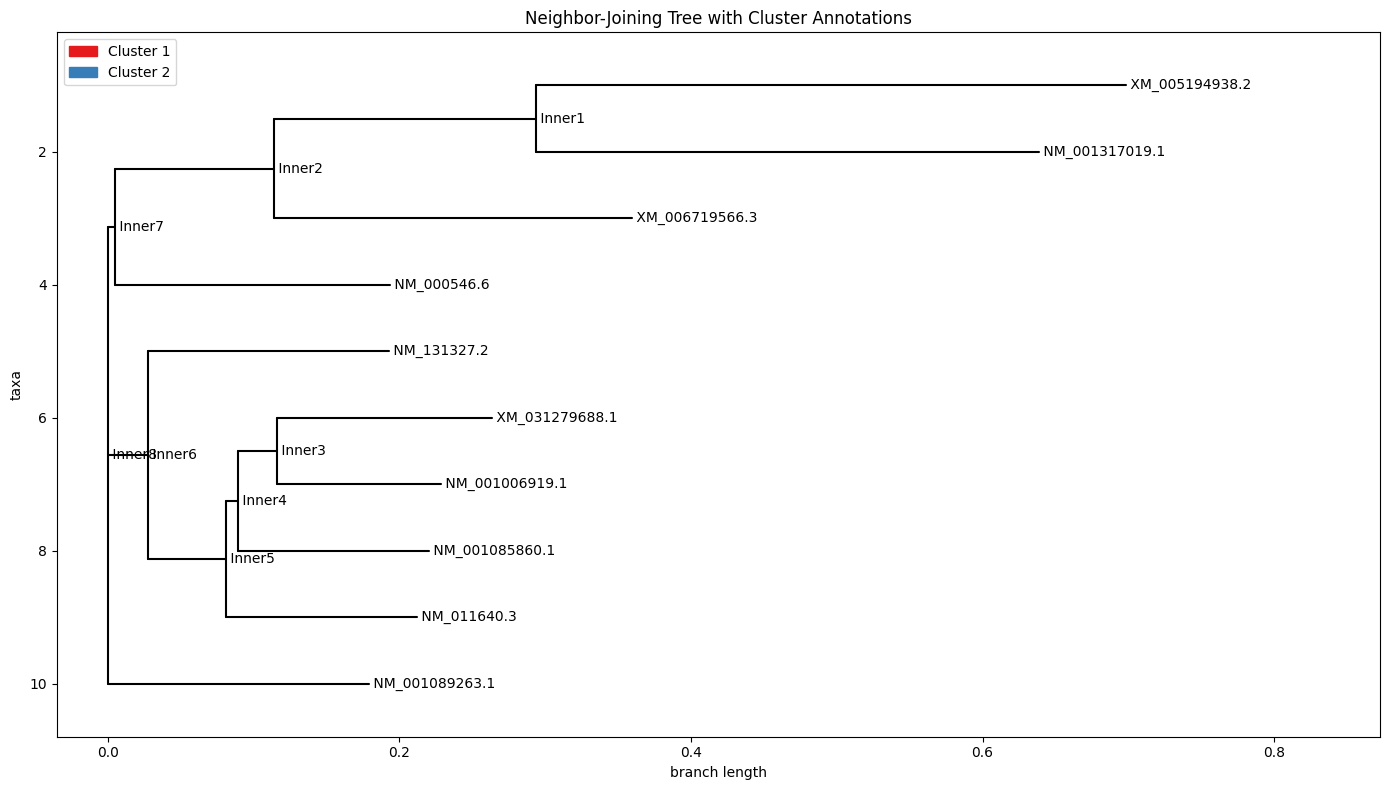

[OK] Annotated tree saved to: /home/rbals/git/daha-bdhb/BDHB-lab/labs/05_clustering/assignments/artifacts/task2_annotated_tree.png


In [11]:
# Create cluster label mapping for visualization
cluster_map = dict(zip(comparison_df["sequence_id"], comparison_df["Cluster"]))

# Define colors for clusters
cluster_colors = {1: "#e41a1c", 2: "#377eb8", 3: "#4daf4a", 4: "#984ea3"}


def get_terminal_colors(tree, cluster_map: Dict) -> Dict:
    """Map terminal names to colors based on cluster assignment."""
    colors = {}
    for terminal in tree.get_terminals():
        cluster = cluster_map.get(terminal.name, 0)
        colors[terminal.name] = cluster_colors.get(cluster, "gray")
    return colors


terminal_colors = get_terminal_colors(tree, cluster_map)

# Visualize tree with matplotlib
fig, ax = plt.subplots(figsize=(14, 8))

# Draw tree
Phylo.draw(tree, axes=ax, do_show=False)

# Add cluster color legend
legend_patches = [
    mpatches.Patch(color=color, label=f"Cluster {cluster}")
    for cluster, color in cluster_colors.items()
    if cluster in cluster_map.values()
]
ax.legend(handles=legend_patches, loc="upper left")

ax.set_title("Neighbor-Joining Tree with Cluster Annotations")
plt.tight_layout()

# Save tree plot
EXPORT_DIR.mkdir(parents=True, exist_ok=True)
tree_fig_path = EXPORT_DIR / "task2_annotated_tree.png"
plt.savefig(tree_fig_path, dpi=150, bbox_inches="tight")
plt.show()
print(f"[OK] Annotated tree saved to: {tree_fig_path.resolve()}")

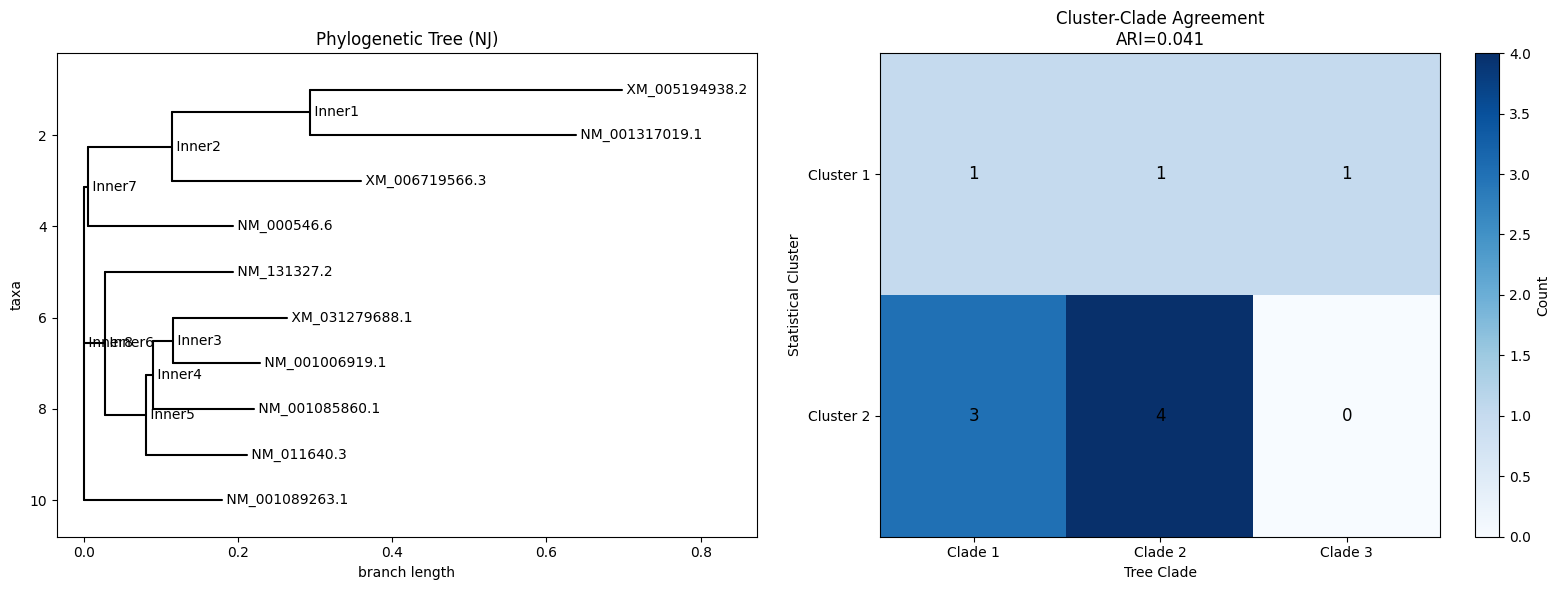

[OK] Comparison figure saved to: /home/rbals/git/daha-bdhb/BDHB-lab/labs/05_clustering/assignments/artifacts/task2_cluster_tree_comparison.png


In [12]:
# Create side-by-side comparison visualization
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Left: Tree structure
ax1 = axes[0]
Phylo.draw(tree, axes=ax1, do_show=False)
ax1.set_title("Phylogenetic Tree (NJ)")

# Right: Cluster vs Tree Clade heatmap
ax2 = axes[1]
contingency = agreement["contingency_table"]
im = ax2.imshow(contingency.values, cmap="Blues", aspect="auto")
ax2.set_xticks(range(len(contingency.columns)))
ax2.set_xticklabels([f"Clade {c}" for c in contingency.columns])
ax2.set_yticks(range(len(contingency.index)))
ax2.set_yticklabels([f"Cluster {c}" for c in contingency.index])
ax2.set_xlabel("Tree Clade")
ax2.set_ylabel("Statistical Cluster")
ax2.set_title(f"Cluster-Clade Agreement\nARI={agreement['adjusted_rand_index']:.3f}")

# Add count annotations
for i in range(len(contingency.index)):
    for j in range(len(contingency.columns)):
        ax2.text(j, i, contingency.values[i, j], ha="center", va="center", fontsize=12)

plt.colorbar(im, ax=ax2, label="Count")
plt.tight_layout()

comparison_fig_path = EXPORT_DIR / "task2_cluster_tree_comparison.png"
plt.savefig(comparison_fig_path, dpi=150)
plt.show()
print(f"[OK] Comparison figure saved to: {comparison_fig_path.resolve()}")

## 7. Validate and Export Results
Save tree, comparison data, and agreement metrics.

In [13]:
def test_tree_terminals_match_sequences():
    tree_terminals = set(t.name for t in tree.get_terminals())
    seq_names = set(seq_ids)
    assert tree_terminals == seq_names, "Tree terminals don't match sequences"


def test_cluster_assignments_complete():
    assert len(comparison_df) == len(sequences)
    assert comparison_df["Cluster"].notna().all()


test_tree_terminals_match_sequences()
test_cluster_assignments_complete()
print("All validation tests passed.")

All validation tests passed.


In [14]:
# Save all artifacts

# 1. Tree in Newick format
tree_path = EXPORT_DIR / "task2_nj_tree.nwk"
Phylo.write(tree, tree_path, "newick")
print(f"[OK] NJ tree saved to: {tree_path.resolve()}")

# 2. Comparison DataFrame
comparison_path = EXPORT_DIR / "task2_cluster_clade_comparison.csv"
comparison_df.to_csv(comparison_path, index=False)
print(f"[OK] Comparison data saved to: {comparison_path.resolve()}")

# 3. Agreement metrics
metrics_to_save = {
    "adjusted_rand_index": agreement["adjusted_rand_index"],
    "normalized_mutual_info": agreement["normalized_mutual_info"],
    "tree_stats": tree_stats,
}

metrics_path = EXPORT_DIR / "task2_agreement_metrics.json"
with open(metrics_path, "w") as f:
    # Remove terminal_names from tree_stats for cleaner JSON
    metrics_clean = metrics_to_save.copy()
    metrics_clean["tree_stats"] = {
        k: v for k, v in tree_stats.items() if k != "terminal_names"
    }
    json.dump(metrics_clean, f, indent=2)
print(f"[OK] Agreement metrics saved to: {metrics_path.resolve()}")

print(f"\nAll Task 2 artifacts saved to {EXPORT_DIR.resolve()}")

[OK] NJ tree saved to: /home/rbals/git/daha-bdhb/BDHB-lab/labs/05_clustering/assignments/artifacts/task2_nj_tree.nwk
[OK] Comparison data saved to: /home/rbals/git/daha-bdhb/BDHB-lab/labs/05_clustering/assignments/artifacts/task2_cluster_clade_comparison.csv
[OK] Agreement metrics saved to: /home/rbals/git/daha-bdhb/BDHB-lab/labs/05_clustering/assignments/artifacts/task2_agreement_metrics.json

All Task 2 artifacts saved to /home/rbals/git/daha-bdhb/BDHB-lab/labs/05_clustering/assignments/artifacts
